In [9]:
import numpy as np
import matplotlib.pyplot as plt

from pyscf import (
    gto,
    scf,
    mcscf,
    ao2mo,
    fci,
)

In [10]:
class BNHActiveSpace:
    """
    BN + H electronic-structure model.

    Returns:
        - ROHF energy
        - CASCI energy
        - effective CAS one-electron integrals
        - CAS two-electron integrals in physicists' ordering
        - CAS core-energy constant
        - full-space FCI energy
        - full-space one- and two-electron integrals
    """

    def __init__(
        self,
        basis="sto-3g",
        bn_bond=1.46,
        h_distance=1.5,
        ncas=3,
        nelecas=(2, 1),
        verbose=0,
    ):
        self.basis = basis
        self.bn_bond = bn_bond
        self.h_distance = h_distance

        self.ncas = ncas
        self.nelecas = tuple(nelecas)

        self.verbose = verbose

        self.mol = None
        self.mf = None
        self.cas = None


    def build_molecule(self):

        self.mol = gto.M(
            atom=f"""
                B  0.0  0.0   0.0
                N  0.0  0.0   {self.bn_bond}
                H  0.0  0.0  {-self.h_distance}
            """,
            basis=self.basis,
            charge=0,
            spin=1,
            unit="Angstrom",
            verbose=self.verbose,
        )

        return self.mol


    def run_rohf(
        self,
        conv_tol=1e-10,
        max_cycle=100,
    ):

        if self.mol is None:
            self.build_molecule()

        self.mf = scf.ROHF(self.mol)

        self.mf.conv_tol = conv_tol
        self.mf.max_cycle = max_cycle

        self.mf.kernel()

        if not self.mf.converged:
            raise RuntimeError(
                f"ROHF did not converge at "
                f"H-B = {self.h_distance:.3f} Å"
            )

        return self.mf


    def run_casci(self):

        if self.mf is None:
            self.run_rohf()

        n_active = sum(self.nelecas)
        n_inactive = self.mol.nelectron - n_active

        if n_inactive < 0 or n_inactive % 2 != 0:
            raise ValueError(
                "Invalid active-electron count: "
                "inactive electrons must form a closed-shell core."
            )

        ncore = n_inactive // 2
        nmo = self.mf.mo_coeff.shape[1]

        if ncore + self.ncas > nmo:
            raise ValueError(
                "Requested active space exceeds available orbitals."
            )

        self.cas = mcscf.CASCI(
            self.mf,
            self.ncas,
            self.nelecas,
        )

        (
            e_tot,
            e_cas,
            ci,
            _,
            _,
        ) = self.cas.kernel(
            self.mf.mo_coeff
        )

        if not self.cas.converged:
            raise RuntimeError(
                "CASCI did not converge."
            )

        h1eff, ecore = self.cas.get_h1eff(
            self.mf.mo_coeff
        )

        eri = self.cas.get_h2eff(
            self.mf.mo_coeff
        )

        eri = ao2mo.restore(
            1,
            eri,
            self.ncas,
        )

        # PySCF chemists' -> physicists' ordering
        eri = np.swapaxes(
            eri,
            1,
            3,
        )

        return {
            "energy": float(e_tot),
            "active_energy": float(e_cas),
            "ci": ci,
            "h1": h1eff,
            "eri": eri,
            "ecore": float(ecore),
            "ncore": ncore,
        }


    def run_full_fci(self):

        if self.mf is None:
            self.run_rohf()

        C = self.mf.mo_coeff
        nmo = C.shape[1]

        h1 = (
            C.T
            @ self.mf.get_hcore()
            @ C
        )

        eri_chem = ao2mo.kernel(
            self.mol,
            C,
        )

        eri_chem = ao2mo.restore(
            1,
            eri_chem,
            nmo,
        )

        solver = fci.direct_spin1.FCI(
            self.mol
        )

        e_fci, ci = solver.kernel(
            h1,
            eri_chem,
            nmo,
            self.mol.nelec,
            ecore=self.mol.energy_nuc(),
        )

        if not solver.converged:
            raise RuntimeError(
                "Full-space FCI did not converge."
            )

        eri_phys = np.swapaxes(
            eri_chem,
            1,
            3,
        )

        return {
            "energy": float(e_fci),
            "ci": ci,
            "h1": h1,
            "eri": eri_phys,
            "enuc": float(
                self.mol.energy_nuc()
            ),
        }

    def run(self):

        self.build_molecule()
        self.run_rohf()

        cas = self.run_casci()
        full = self.run_full_fci()

        nmo_full = self.mf.mo_coeff.shape[1]

        return {
            "system": {
                "h_distance": self.h_distance,
                "bn_bond": self.bn_bond,
                "basis": self.basis,
                "nelectrons": self.mol.nelec,
            },

            "energies": {
                "rohf": float(self.mf.e_tot),
                "casci": cas["energy"],
                "casci_active": cas["active_energy"],
                "full_fci": full["energy"],
            },

            "cas": {
                "ncas": self.ncas,
                "nelecas": self.nelecas,
                "nqubits": 2 * self.ncas,

                "h1": cas["h1"],
                "eri": cas["eri"],      # physicists' ordering
                "ecore": cas["ecore"],
            },

            "full_space": {
                "nmo": nmo_full,
                "nelec": self.mol.nelec,
                "nqubits": 2 * nmo_full,

                "h1": full["h1"],
                "eri": full["eri"],     # physicists' ordering
                "enuc": full["enuc"],
            },
        }


In [11]:
# H-B distances
distances = np.arange(0.7, 1.8, 0.1)

cas55 = []
cas77 = []
cas99 = []
fci_pyscf = []


for R in distances:

    print(f"R = {R:.2f} Å")

    # CAS(5,5)
    model = BNHActiveSpace(
        h_distance=R,
        ncas=5,
        nelecas=(3, 2),
    )
    result = model.run()

    cas55.append(result["energies"]["casci"])
    fci_pyscf.append(result["energies"]["full_fci"])


    # CAS(7,7)
    model = BNHActiveSpace(
        h_distance=R,
        ncas=7,
        nelecas=(4, 3),
    )
    result = model.run()

    cas77.append(result["energies"]["casci"])


    # CAS(9,9)
    model = BNHActiveSpace(
        h_distance=R,
        ncas=9,
        nelecas=(5, 4),
    )
    result = model.run()

    cas99.append(result["energies"]["casci"])


# Convert to arrays
cas55 = np.array(cas55)
cas77 = np.array(cas77)
cas99 = np.array(cas99)
fci_pyscf = np.array(fci_pyscf)

R = 0.70 Å
R = 0.80 Å
R = 0.90 Å
R = 1.00 Å
R = 1.10 Å
R = 1.20 Å
R = 1.30 Å
R = 1.40 Å
R = 1.50 Å
R = 1.60 Å
R = 1.70 Å


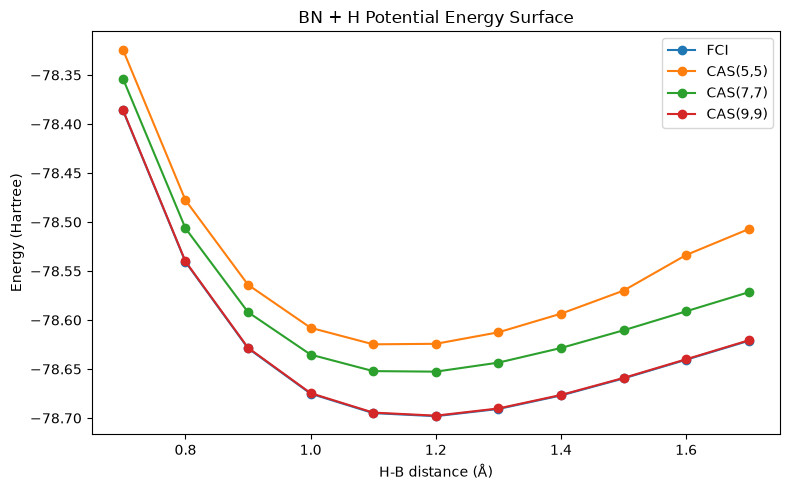

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(distances, fci_pyscf, "o-", label="FCI")
plt.plot(distances, cas55, "o-", label="CAS(5,5)")
plt.plot(distances, cas77, "o-", label="CAS(7,7)")
plt.plot(distances, cas99, "o-", label="CAS(9,9)")

plt.xlabel("H-B distance (Å)")
plt.ylabel("Energy (Hartree)")
plt.title("BN + H Potential Energy Surface")

plt.legend()
plt.tight_layout()
plt.show()

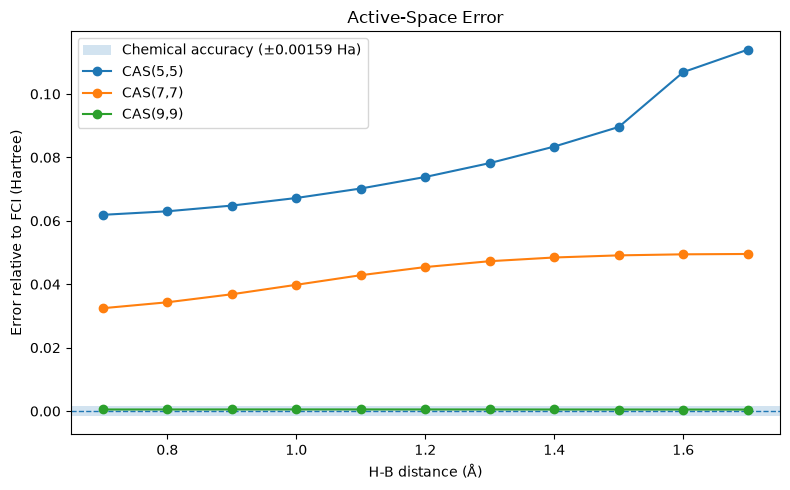

In [15]:
chemical_accuracy = 1.0 / 627.509  # Hartree

error55 = cas55 - fci_pyscf
error77 = cas77 - fci_pyscf
error99 = cas99 - fci_pyscf


plt.figure(figsize=(8, 5))

# Chemical accuracy: ±1 kcal/mol ≈ ±0.00159 Ha
plt.axhspan(
    -chemical_accuracy,
    chemical_accuracy,
    alpha=0.2,
    label=r"Chemical accuracy ($\pm 0.00159$ Ha)",
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.plot(
    distances,
    error55,
    "o-",
    label="CAS(5,5)",
)

plt.plot(
    distances,
    error77,
    "o-",
    label="CAS(7,7)",
)

plt.plot(
    distances,
    error99,
    "o-",
    label="CAS(9,9)",
)

plt.xlabel("H-B distance (Å)")
plt.ylabel("Error relative to FCI (Hartree)")
plt.title("Active-Space Error")

plt.legend()
plt.tight_layout()
plt.show()

araf tests

In [ ]:



# ============================================================
# PES settings
# ============================================================

distances = np.arange(
    0.7,
    1.8,
    0.1,
)

cas_spaces = {
    "CAS(5,5)": {
        "ncas": 5,
        "nelecas": (3, 2),
    },
    "CAS(7,7)": {
        "ncas": 7,
        "nelecas": (4, 3),
    },
    "CAS(9,9)": {
        "ncas": 9,
        "nelecas": (5, 4),
    },
}


# ============================================================
# Storage
# ============================================================

energies = {
    "CAS(5,5)": [],
    "CAS(7,7)": [],
    "CAS(9,9)": [],
    "FCI": [],
}


# ============================================================
# PES scan
# ============================================================

for R in distances:

    print(f"\nH-B distance = {R:.2f} Å")

    # --------------------------------------------------------
    # Run CAS(5,5), CAS(7,7), CAS(9,9)
    # --------------------------------------------------------

    for label, settings in cas_spaces.items():

        try:

            model = BNHActiveSpace(
                basis="sto-3g",
                bn_bond=1.281,
                h_distance=R,
                ncas=settings["ncas"],
                nelecas=settings["nelecas"],
                verbose=0,
            )

            result = model.run()

            E_cas = result[
                "energies"
            ]["casci"]

            energies[label].append(
                E_cas
            )

            print(
                f"{label:10s}: "
                f"{E_cas:.10f}"
            )

            # Full FCI is independent of the CAS choice,
            # so only save it once per geometry.
            if label == "CAS(5,5)":

                E_fci = result[
                    "energies"
                ]["full_fci"]

                energies["FCI"].append(
                    E_fci
                )

                print(
                    f"{'FCI':10s}: "
                    f"{E_fci:.10f}"
                )

        except Exception as err:

            print(
                f"{label} failed at "
                f"R = {R:.2f} Å:"
            )

            print(err)

            energies[label].append(
                np.nan
            )

            if label == "CAS(5,5)":

                energies["FCI"].append(
                    np.nan
                )

In [ ]:
# ============================================================
# Absolute PES
# ============================================================

plt.figure(
    figsize=(9, 6)
)

for label in [
    "CAS(5,5)",
    "CAS(7,7)",
    "CAS(9,9)",
    "FCI",
]:

    plt.plot(
        distances,
        energies[label],
        marker="o",
        label=label,
    )

plt.xlabel(
    "H-B distance (Å)"
)

plt.ylabel(
    "Energy (Hartree)"
)

plt.title(
    "BN + H Potential Energy Surface"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
